In [2]:
#Importações
import pygad
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Função objetivo
def f(x):
    return 1 - x**2

def fitness_func(ga_instance, solution, solution_idx):
    return f(solution[0])

In [4]:
#Configuração do GA
num_generations = 30
sol_per_pop = 8
num_parents_mating = 4
a, b = -2, 2

ga = pygad.GA(
    num_generations=num_generations,
    num_parents_mating=num_parents_mating,
    sol_per_pop=sol_per_pop,
    num_genes=1,
    fitness_func=fitness_func,
    gene_space=[{'low': a, 'high': b}],
    mutation_probability=0.1,
    crossover_type="single_point",
    keep_elitism=1
)

In [5]:
# Executar AG
ga.run()

In [6]:
#Resultados
sol, fit, _ = ga.best_solution()
print(f"Melhor x = {sol[0]:.6f}")
print(f"Melhor f(x) = {fit:.6f}")

Melhor x = -0.001090
Melhor f(x) = 0.999999


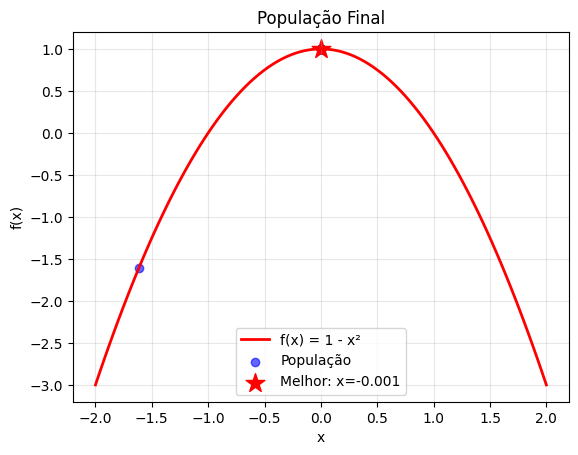

In [7]:
#Gráfico da população final
x_plot = np.linspace(-2, 2, 100)
plt.plot(x_plot, f(x_plot), 'r-', linewidth=2, label='f(x) = 1 - x²')

populacao = ga.population
plt.scatter(populacao, f(populacao), c='blue', alpha=0.6, label='População')
plt.scatter(sol[0], fit, c='red', s=200, marker='*', label=f'Melhor: x={sol[0]:.3f}')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('População Final')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

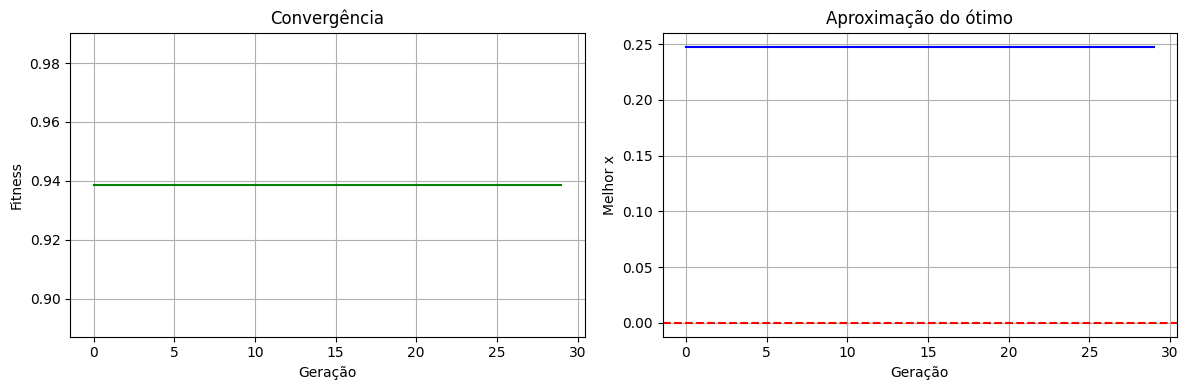

In [8]:
#Com callback para histórico detalhado
historico_fitness = []
historico_x = []

def callback(ga):
    historico_fitness.append(ga.best_solution()[1])
    historico_x.append(ga.best_solution()[0][0])

ga2 = pygad.GA(
    num_generations=30,
    num_parents_mating=4,
    sol_per_pop=8,
    num_genes=1,
    fitness_func=fitness_func,
    gene_space=[{'low': -2, 'high': 2}],
    mutation_probability=0.1,
    on_generation=callback
)

ga2.run()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(historico_fitness, 'g-')
ax1.set_xlabel('Geração')
ax1.set_ylabel('Fitness')
ax1.set_title('Convergência')
ax1.grid(True)

ax2.plot(historico_x, 'b-')
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Geração')
ax2.set_ylabel('Melhor x')
ax2.set_title('Aproximação do ótimo')
ax2.grid(True)

plt.tight_layout()
plt.show()